In [1]:
%load_ext autoreload
%autoreload 2

In [13]:
import time
from src.crawl_news import ConfigManager, CSVStorageManager, ArticleParser, CrawlOrchestrator
import yaml

In [3]:
config_path = "../sites_config.yaml"
csv_output_path = "../data/crawl/raw_crawled_articles_25022026.csv"

In [4]:
config = ConfigManager(config_path)
storage = CSVStorageManager(csv_output_path)
parser = ArticleParser()

In [5]:
# Khoi tao CrawlOrchestrator voi cac doi tuong 
# cau hinh, luu tru va phan tich bai viet da duoc tao o tren, 
# sau do thuc hien viec crawl du lieu tu cac trang tin tuc duoc cau hinh san trong file sites_config.yaml
scraper_engine = CrawlOrchestrator(config, storage, parser)

In [6]:
# chay crawl 
start_time = time.time()
scraper_engine.run(max_pages=2, max_workers=5)
end_time = time.time()

print(f"\nExecution finished in {(end_time - start_time) / 60:.2f} minutes")

=== COLLECTING URLS ===

 Scanning Category: Thời sự
   -> Target: vnexpress.net | Category Link: https://vnexpress.net/thoi-su
      - Fetching Page 1: https://vnexpress.net/thoi-su
 > Found 50 links on this page.
      - Fetching Page 2: https://vnexpress.net/thoi-su-p2
 > Found 29 links on this page.
   -> Target: thanhnien.vn | Category Link: https://thanhnien.vn/thoi-su
      - Fetching Page 1: https://thanhnien.vn/thoi-su
 > Found 35 links on this page.
      - Fetching Page 2: https://thanhnien.vn/thoi-su/trang-2.htm
 > Found 1 links on this page.
   -> Target: dantri.com.vn | Category Link: https://dantri.com.vn/xa-hoi
      - Fetching Page 1: https://dantri.com.vn/xa-hoi
   [Lỗi 404] Tại https://dantri.com.vn/xa-hoi
Failed to retrieve HTML (Timeout or Blocked).
      - Fetching Page 2: https://dantri.com.vn/xa-hoi/trang-2.htm
 > Found 44 links on this page.
   -> Target: tuoitre.vn | Category Link: https://tuoitre.vn/thoi-su
      - Fetching Page 1: https://tuoitre.vn/thoi-su


**Collect imbalance Data**
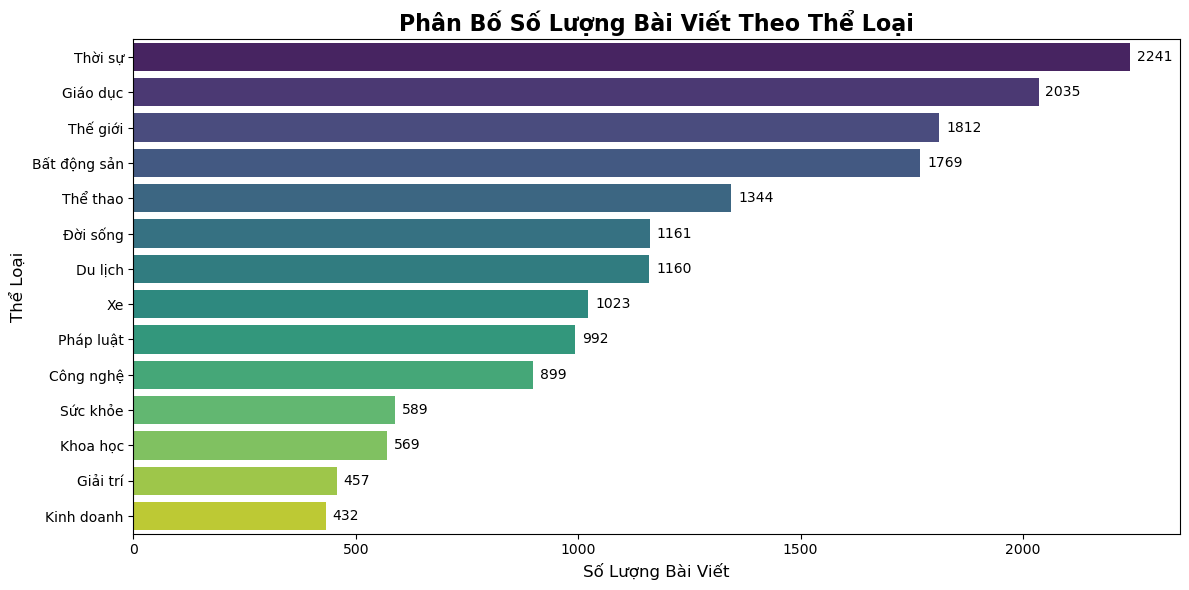



- Nhung the loai dang bi thieu qua nhieu la:
    - Kinh doanh
    - Giai tri
    - Khoa hoc
    - Suc khoe
    - Cong nghe 
    - Phap luat
    - Xe
    - Du lich
    - Doi song
    
Moi the loai se thu thap them khoang 1000 mau data nua de can bang cac lop

In [14]:
imbalance_config_path = "../imbalance_collect_config.yaml"
imbalance_csv_output_path = "../data/crawl/raw_crawled_articles_26022026.csv"

In [4]:
try:
    with open(imbalance_config_path, 'r', encoding='utf-8') as f:
        imbalance_config = yaml.safe_load(f)
except FileNotFoundError:
    print(f"Error: File {imbalance_config_path} not found.")
    imbalance_config = {}

# sites = config["sites"]
# categories = config["categories"]

In [6]:
sites = imbalance_config.get("sites", [])
categories = imbalance_config.get("categories", [])

In [11]:
print(sites.keys())
print(categories.keys())

dict_keys(['vnexpress.net', 'thanhnien.vn', 'dantri.com.vn', 'tuoitre.vn', 'vietnamnet.vn'])
dict_keys(['Kinh doanh', 'Công nghệ', 'Giải trí', 'Sức khỏe', 'Pháp luật', 'Khoa học', 'Xe', 'Du lịch', 'Đời sống'])


In [17]:
i_config = ConfigManager(imbalance_config_path)
i_storage = CSVStorageManager(imbalance_csv_output_path)
i_parser = ArticleParser()

i_scraper_engine = CrawlOrchestrator(i_config, i_storage, i_parser)

# chay crawl 
start_time = time.time()
i_scraper_engine.run(max_pages=35, max_workers=4)
end_time = time.time()

print(f"\nExecution finished in {(end_time - start_time) / 60:.2f} minutes")

=== COLLECTING URLS ===

 Scanning Category: Kinh doanh
   -> Target: vnexpress.net | Category Link: https://vnexpress.net/kinh-doanh
      - Fetching Page 1: https://vnexpress.net/kinh-doanh
 > Found 53 links on this page.
      - Fetching Page 2: https://vnexpress.net/kinh-doanh-p2
 > Found 0 links on this page.
      - Fetching Page 3: https://vnexpress.net/kinh-doanh-p3
 > Found 0 links on this page.
      - Fetching Page 4: https://vnexpress.net/kinh-doanh-p4
 > Found 0 links on this page.
      - Fetching Page 5: https://vnexpress.net/kinh-doanh-p5
 > Found 0 links on this page.
      - Fetching Page 6: https://vnexpress.net/kinh-doanh-p6
 > Found 0 links on this page.
      - Fetching Page 7: https://vnexpress.net/kinh-doanh-p7
 > Found 0 links on this page.
      - Fetching Page 8: https://vnexpress.net/kinh-doanh-p8
 > Found 0 links on this page.
      - Fetching Page 9: https://vnexpress.net/kinh-doanh-p9
 > Found 0 links on this page.
      - Fetching Page 10: https://vnexpr

# Crawl data mới mỗi ngày

In [7]:
import time
from src.crawl_news import ConfigManager, CSVStorageManager, ArticleParser, CrawlOrchestrator
import yaml
from datetime import datetime

In [8]:
config_path = "../sites_config.yaml"
csv_output_path = f"../data/crawl/raw_crawled_articles_{datetime.now().strftime('%d%m%Y')}.csv"

In [9]:
config = ConfigManager(config_path)
storage = CSVStorageManager(csv_output_path)
parser = ArticleParser()

scraper_engine = CrawlOrchestrator(config, storage, parser)

In [10]:
# chay crawl 
start_time = time.time()
scraper_engine.run(max_pages=2, max_workers=5)
end_time = time.time()

print(f"\nExecution finished in {(end_time - start_time) / 60:.2f} minutes")

=== COLLECTING URLS ===

 Scanning Category: Thời sự
   -> Target: vnexpress.net | Category Link: https://vnexpress.net/thoi-su
      - Fetching Page 1: https://vnexpress.net/thoi-su
 > Found 50 links on this page.
      - Fetching Page 2: https://vnexpress.net/thoi-su-p2
 > Found 29 links on this page.
   -> Target: thanhnien.vn | Category Link: https://thanhnien.vn/thoi-su
      - Fetching Page 1: https://thanhnien.vn/thoi-su
 > Found 34 links on this page.
      - Fetching Page 2: https://thanhnien.vn/thoi-su/trang-2.htm
 > Found 1 links on this page.
   -> Target: dantri.com.vn | Category Link: https://dantri.com.vn/xa-hoi
      - Fetching Page 1: https://dantri.com.vn/xa-hoi
   [Lỗi 404] Tại https://dantri.com.vn/xa-hoi
Failed to retrieve HTML (Timeout or Blocked).
      - Fetching Page 2: https://dantri.com.vn/xa-hoi/trang-2.htm
 > Found 44 links on this page.
   -> Target: tuoitre.vn | Category Link: https://tuoitre.vn/thoi-su
      - Fetching Page 1: https://tuoitre.vn/thoi-su
